In [43]:
import pandas as pd

In [44]:
data = pd.read_csv("agriculture_ml_dataset_cw.csv")

In [45]:
data.shape

(2020, 11)

In [46]:
data.columns

Index(['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation',
       'Fertilizer', 'Rainfall', 'Temperature', 'Humidity', 'Nitrogen',
       'Yield'],
      dtype='object')

In [47]:
data.head(10)

,Crop_Type,Soil_Type,Region,Season,Irrigation,Fertilizer,Rainfall,Temperature,Humidity,Nitrogen,Yield
0,Wheat,Silty,South,Kharif,Sprinkler,Chemical,93.7,22.9,69.0,115.0,5.13
1,Cotton,NaN,West,Zaid,Flood,Organic,146.9,25.6,NaN,71.0,5.40
2,Cotton,Clay,North,Kharif,Drip,Chemical,108.7,22.1,NaN,86.0,4.26
3,Maize,Clay,South,Kharif,Sprinkler,Chemical,72.3,26.8,69.4,44.0,4.35
4,Maize,Silty,West,Kharif,Flood,Organic,119.9,26.3,44.3,48.0,4.88
5,Sugarcane,Loamy,West,Rabi,Flood,Mixed,176.4,NaN,83.3,72.0,4.70
6,Wheat,Clay,South,Rabi,Sprinkler,Chemical,146.1,NaN,72.9,97.0,6.82
7,Cotton,Loamy,East,Zaid,NaN,Organic,200.6,26.8,53.6,101.0,6.88
8,Rice,Silty,North,Rabi,Drip,Mixed,136.2,31.3,58.5,111.0,6.26
9,Wheat,Sandy,North,Rabi,Sprinkler,Organic,215.7,26.2,70.8,55.0,6.92


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Crop_Type    2020 non-null   object 
 1   Soil_Type    1899 non-null   object 
 2   Region       2020 non-null   object 
 3   Season       2020 non-null   object 
 4   Irrigation   1900 non-null   object 
 5   Fertilizer   2020 non-null   object 
 6   Rainfall     1899 non-null   float64
 7   Temperature  1900 non-null   float64
 8   Humidity     1898 non-null   float64
 9   Nitrogen     1899 non-null   float64
 10  Yield        2020 non-null   float64
dtypes: float64(5), object(6)
memory usage: 173.7+ KB


In [49]:
data.describe()

,Rainfall,Temperature,Humidity,Nitrogen,Yield
count,1899.000000,1900.000000,1898.000000,1899.000000,2020.000000
mean,129.723960,26.875421,67.740622,79.169036,5.442926
std,35.395931,4.104174,12.046501,22.876734,1.062772
min,22.800000,12.900000,30.600000,40.000000,1.740000
25%,107.100000,24.200000,59.500000,59.000000,4.700000
50%,128.100000,26.900000,67.650000,79.000000,5.430000
75%,153.500000,29.600000,75.800000,99.000000,6.172500
max,245.300000,43.100000,117.800000,119.000000,8.910000


In [50]:
data.isnull().sum()

,0
Crop_Type,0
Soil_Type,121
Region,0
Season,0
Irrigation,120
Fertilizer,0
Rainfall,121
Temperature,120
Humidity,122
Nitrogen,121


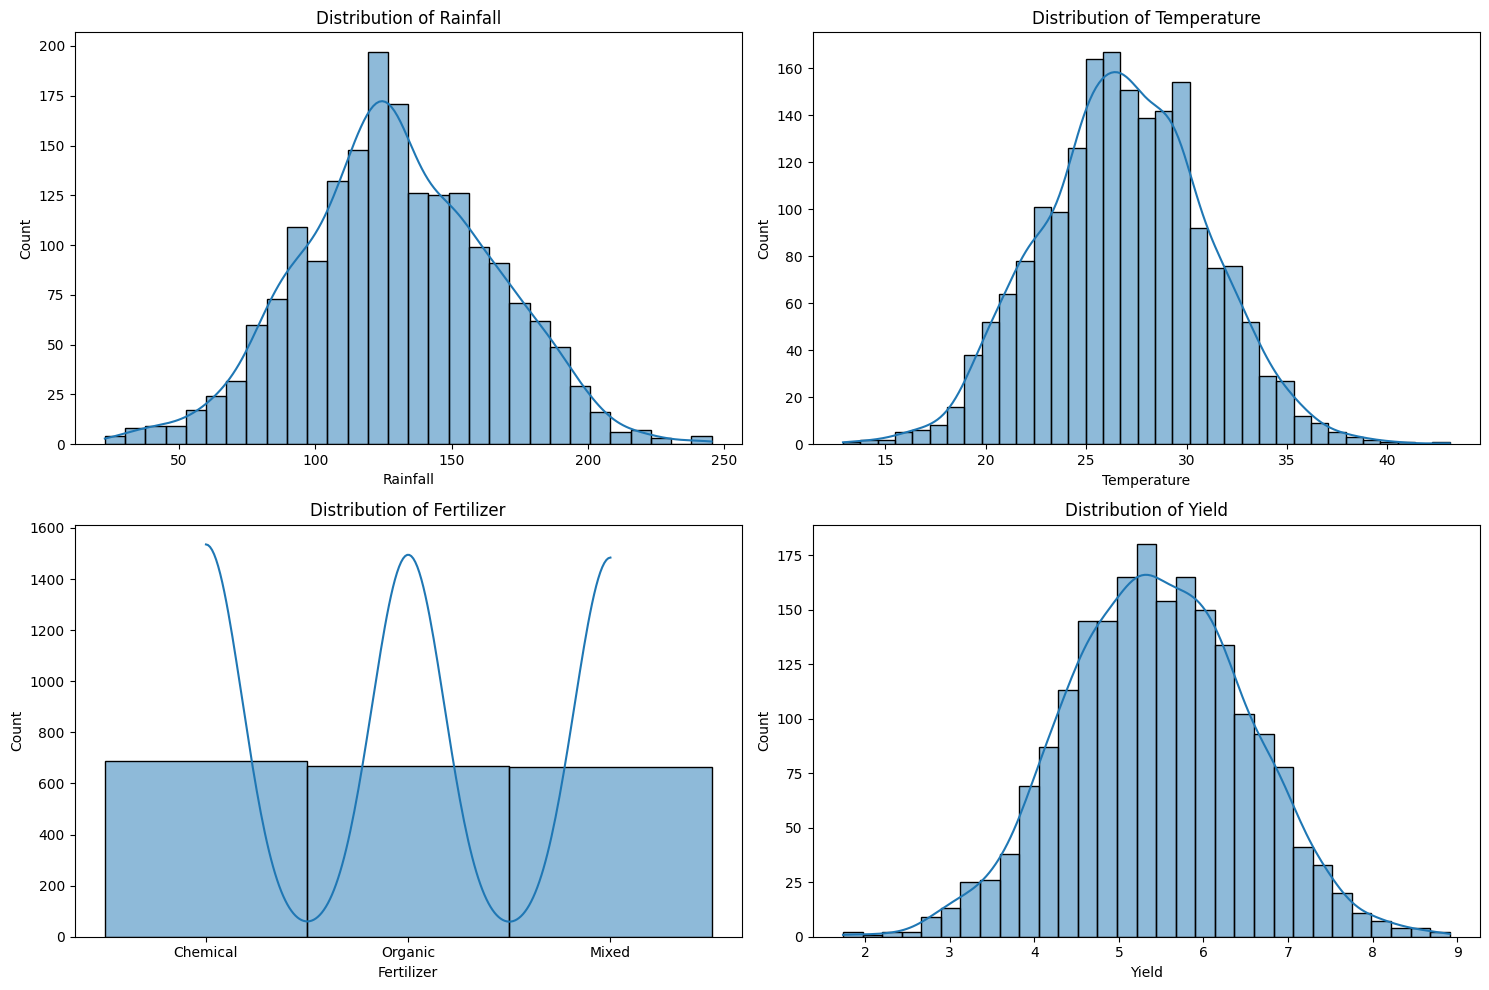

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns


features = ["Rainfall", "Temperature", "Fertilizer", "Yield"]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data[feature], kde=True)
    plt.title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()


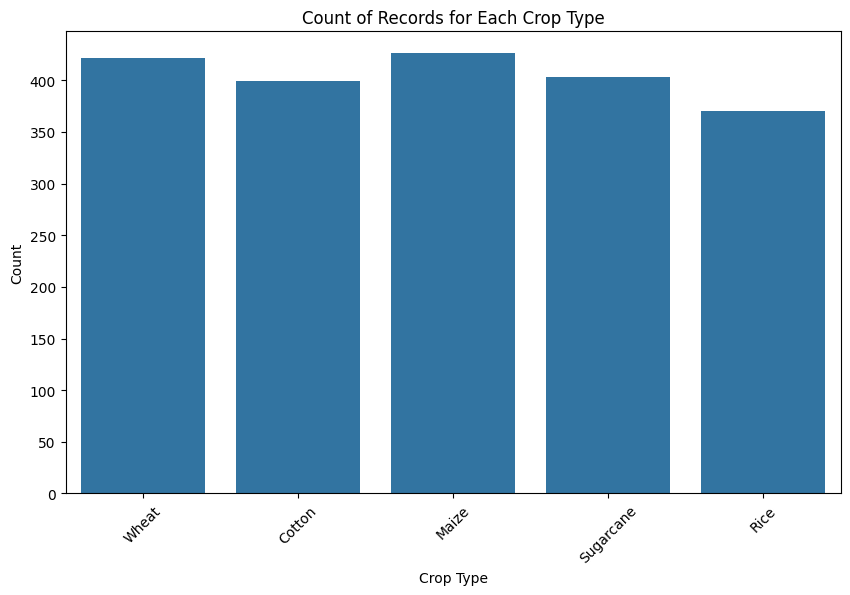

In [52]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Crop_Type", data=data)
plt.title("Count of Records for Each Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [53]:
data['Soil_Type'].value_counts()

,count
Soil_Type,
Silty,493
Loamy,482
Clay,463
Sandy,461


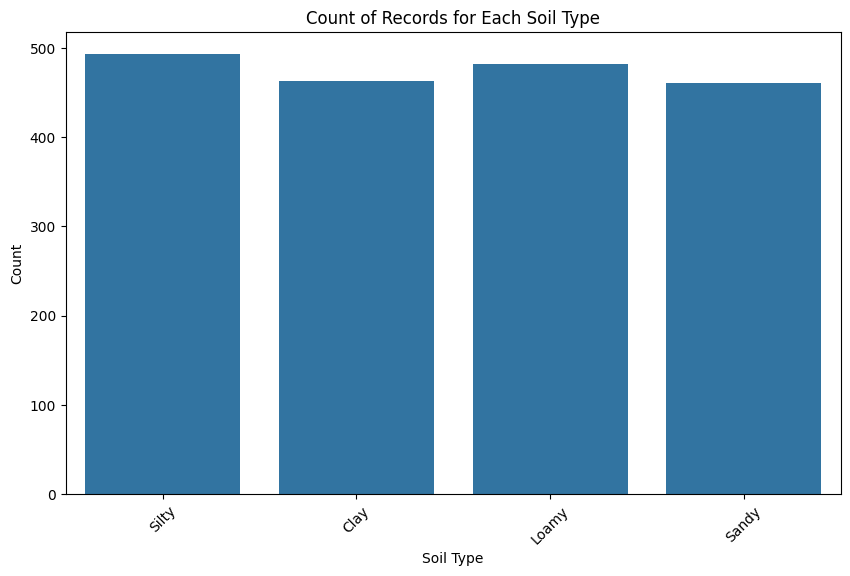

In [54]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Soil_Type', data=data)
plt.title('Count of Records for Each Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


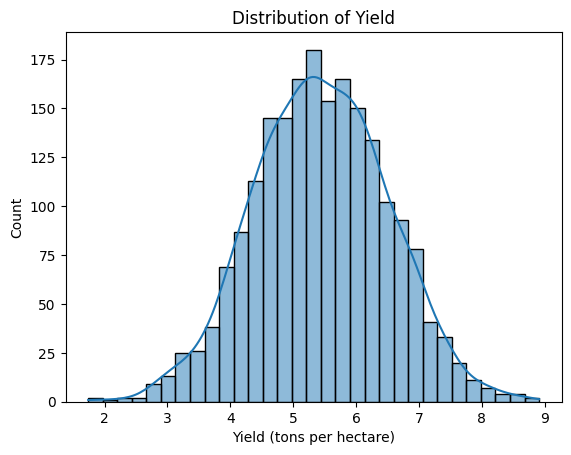

In [55]:
sns.histplot(data['Yield'], kde=True)
plt.title('Distribution of Yield')
plt.xlabel('Yield (tons per hectare)')
plt.ylabel('Count')
plt.show()

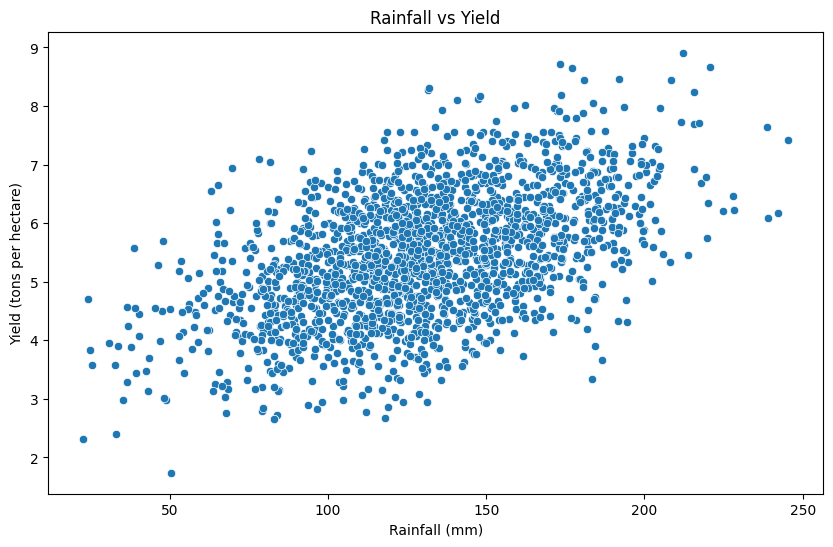

In [56]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rainfall', y='Yield', data=data)
plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (tons per hectare)')
plt.show()


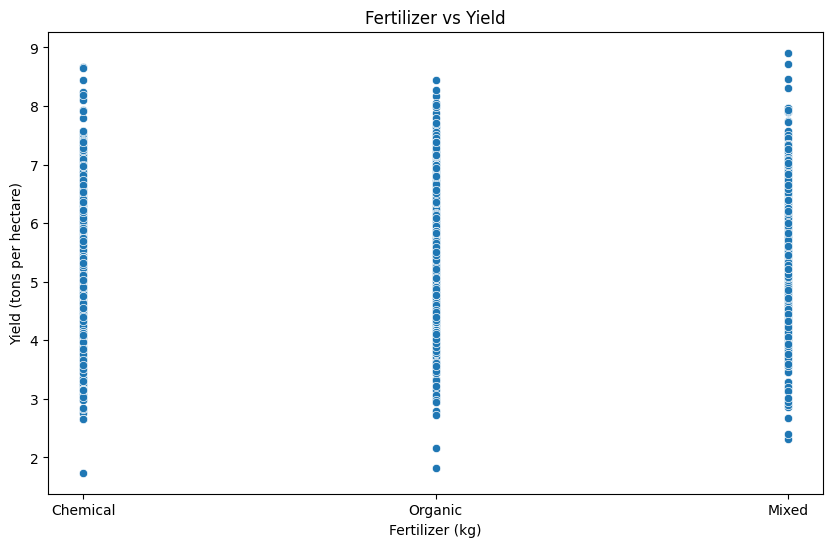

In [57]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Fertilizer', y='Yield', data=data)
plt.title('Fertilizer vs Yield')
plt.xlabel('Fertilizer (kg)')
plt.ylabel('Yield (tons per hectare)')
plt.show()


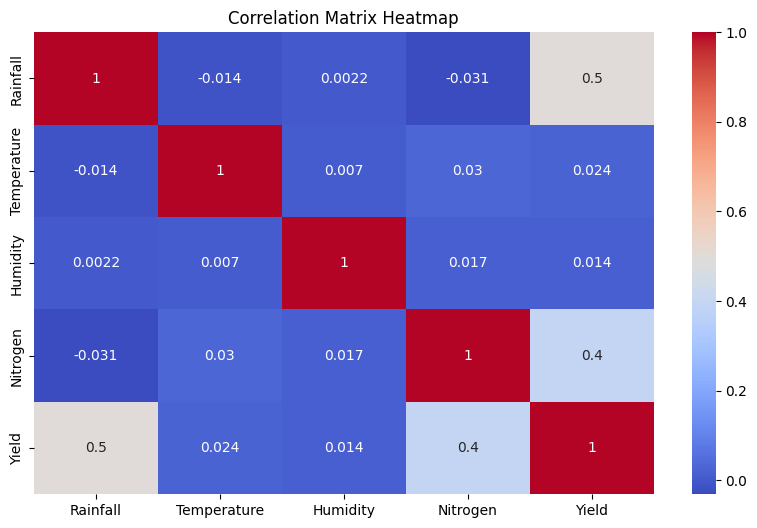

Yield          1.000000
Rainfall       0.498788
Nitrogen       0.395801
Temperature    0.023503
Name: Yield, dtype: float64


In [58]:
plt.figure(figsize=(10, 6))
numerical_data = data.select_dtypes(include=['number'])
correlation_matrix = numerical_data.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

print(correlation_matrix['Yield'].abs().nlargest(4))


In [59]:
# Average yield for each crop type
crop_yield = data.groupby('Crop_Type')['Yield'].mean()
print("Average Yield by Crop Type:")
print(crop_yield)

# Average yield for each soil type
soil_yield = data.groupby('Soil_Type')['Yield'].mean()
print("\nAverage Yield by Soil Type:")
print(soil_yield)
# Average yield for each crop type
crop_yield = data.groupby('Crop_Type')['Yield'].mean()
print("Average Yield by Crop Type:")
print(crop_yield)

# Average yield for each soil type
soil_yield = data.groupby('Soil_Type')['Yield'].mean()
print("\nAverage Yield by Soil Type:")
print(soil_yield)


Average Yield by Crop Type:
Crop_Type
Cotton       5.434286
Maize        5.439014
Rice         5.368919
Sugarcane    5.445434
Wheat        5.517536
Name: Yield, dtype: float64

Average Yield by Soil Type:
Soil_Type
Clay     5.509352
Loamy    5.347427
Sandy    5.452777
Silty    5.439919
Name: Yield, dtype: float64
Average Yield by Crop Type:
Crop_Type
Cotton       5.434286
Maize        5.439014
Rice         5.368919
Sugarcane    5.445434
Wheat        5.517536
Name: Yield, dtype: float64

Average Yield by Soil Type:
Soil_Type
Clay     5.509352
Loamy    5.347427
Sandy    5.452777
Silty    5.439919
Name: Yield, dtype: float64


In [60]:
# Identify categorical columns
categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Apply One-Hot Encoding
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Display the first five rows of the transformed dataset
print(data_encoded.head())


Categorical columns: ['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation', 'Fertilizer']
   Rainfall  Temperature  Humidity  Nitrogen  Yield  Crop_Type_Maize  \
0      93.7         22.9      69.0     115.0   5.13            False   
1     146.9         25.6       NaN      71.0   5.40            False   
2     108.7         22.1       NaN      86.0   4.26            False   
3      72.3         26.8      69.4      44.0   4.35             True   
4     119.9         26.3      44.3      48.0   4.88             True   

   Crop_Type_Rice  Crop_Type_Sugarcane  Crop_Type_Wheat  Soil_Type_Loamy  ...  \
0           False                False             True            False  ...   
1           False                False            False            False  ...   
2           False                False            False            False  ...   
3           False                False            False            False  ...   
4           False                False            False           

In [61]:
x=data_encoded.drop('Yield',axis=1)
y=data_encoded['Yield']
print(x.shape)
print(y.shape)

(2020, 20)
(2020,)


In [62]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1616, 20)
(404, 20)
(1616,)
(404,)
